In [38]:
import pandas as pd


In [39]:
file_path = 'Titanic.csv'
def read_file(file_path):
    return pd.read_csv(file_path).head()
read_file(file_path)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [40]:
df = pd.read_csv('Titanic.csv')
cols = ['PassengerId','Name','Ticket']
df.drop(cols, axis= 1, inplace= True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [ ]:
from config import COLS_DROP
from preprocessing import drop_cols
drop_cols(df,COLS_DROP)

ModuleNotFoundError: No module named 'config'

In [ ]:
df.head()

In [ ]:
dtypes = df.dtypes
nunique = df.nunique()
pd.DataFrame({"dtypes":dtypes, "nunique": nunique }).T

In [ ]:
cat_cols= ["Survived","Pclass","Sex","SibSp","Parch","Embarked"]
df[cat_cols] = df[cat_cols].astype("category")


In [ ]:
def get_type_Info(df):
    return pd.DataFrame({"dtypes":df.dtypes, "nunique": df.nunique() }).T

In [ ]:
get_type_Info(df)

In [ ]:
df.select_dtypes("category")

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
null = df.isnull().sum()
ratio = (null / 891)*100
ratio

In [ ]:
df = df.dropna(subset=['Embarked'])

In [ ]:
df = df.drop("Cabin",axis=1)

In [ ]:
# df.describe()
median = df['Age'].median()
df['Age']  = df['Age'].fillna(median, inplace=True)

In [ ]:
null = df.isnull().sum()
ratio = (null / 891)*100
pd.DataFrame({"null":null, "ratio": ratio }).T

In [ ]:
col_num=df.select_dtypes("number").columns
for col in col_num:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(.75)
    IQR=Q3-Q1
    lower_fence=Q1-1.5*IQR
    upper_fence=Q3+1.5*IQR
    #print(lower_fence,upper_fence)
    lower_outliers=df[          df[col]<lower_fence          ][col].values
    upper_outliers=df[          df[col]<upper_fence          ][col].values

    df[col]= df[col].replace(lower_outliers,lower_fence)
    df[col]= df[col].replace(upper_outliers,upper_fence)

ValueError: num must be an integer with 1 <= num <= 2, not 3

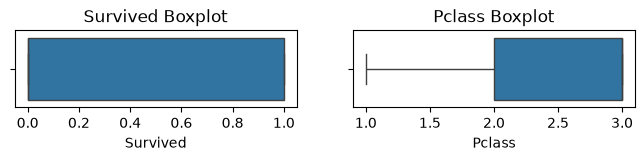

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,1))
for i ,col in enumerate(col_num):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient='h')
    plt.title(f"{col} Boxplot")
plt.show()


In [ ]:
col_num=df.select_dtypes("number").columns
for col in col_num:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(.75)
    IQR=Q3-Q1
    lower_fence=Q1-1.5*IQR
    upper_fence=Q3+1.5*IQR

    df[col].clip(lower_fence,upper_fence)
 

In [ ]:
df.duplicated().sum()

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

In [ ]:
def remove_duplicate(df,subset_cols=None,keep_strategy="first"):
    return (df.drop_duplicates(subset=subset_cols,keep=keep_strategy)).reset_index(drop=True)


In [ ]:
num_col=df.select_dtypes("number").columns


ValueError: num must be an integer with 1 <= num <= 2, not 3

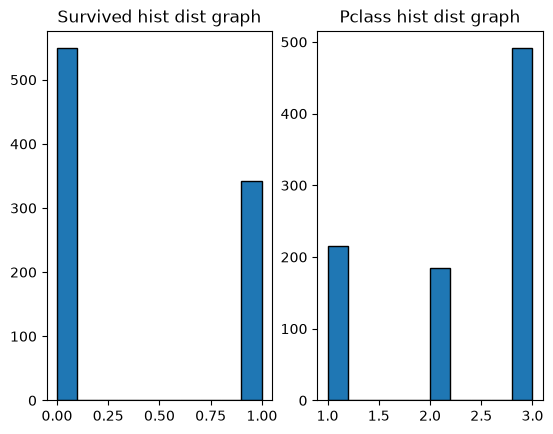

In [44]:
plt.Figure(figsize=(9,2))
for i ,col in enumerate(num_col):
    plt.subplot(1,2,i+1)
    plt.hist(df[col],edgecolor='black')
    plt.title(f"{col} hist dist graph")
plt.show()    

ValueError: num must be an integer with 1 <= num <= 2, not 3

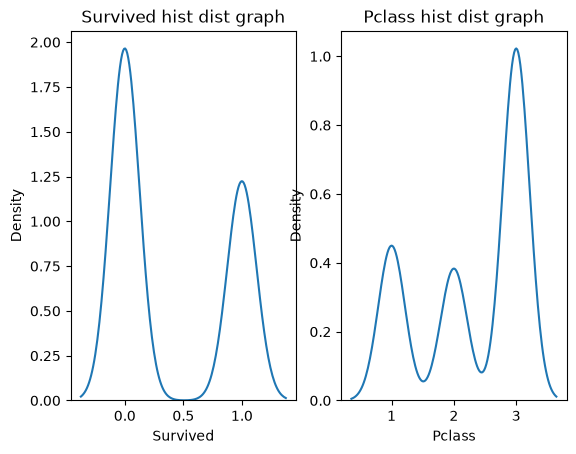

In [45]:
plt.Figure(figsize=(9,2))
for i ,col in enumerate(num_col):
    plt.subplot(1,2,i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist dist graph")
plt.show()    

ValueError: num must be an integer with 1 <= num <= 6, not 7

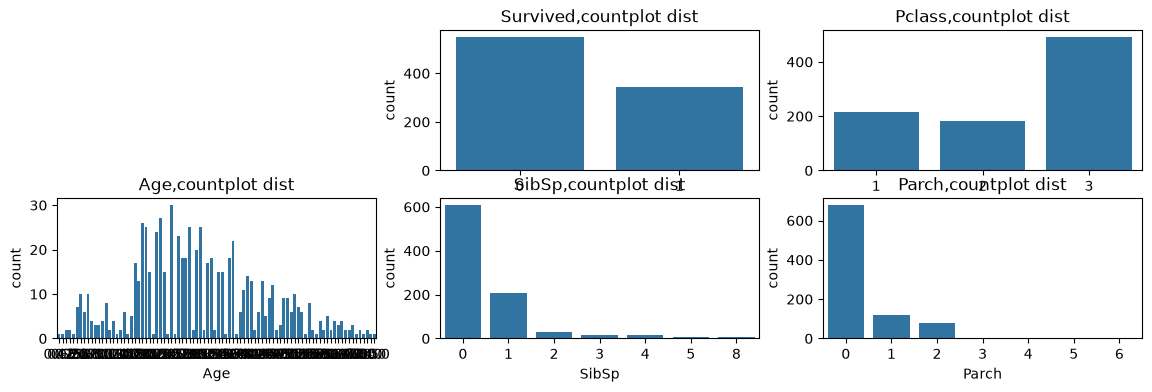

In [48]:
cat_col=df.select_dtypes("number").columns
plt.figure(figsize=(14,4))
for i , col in enumerate(cat_col):
    plt.subplot(2,3,i+2)
    sns.countplot(x=col,data=df)
    plt.title(f"{col},countplot dist")
plt.subplots_adjust(hspace=0.8,wspace=0.3)

In [49]:
plt.Figure(figsize=(9,4))
for i , col in enumerate(cat_col):
    plt.Subplot(2,3,i+1)
    

TypeError: subplot() takes 1 or 3 positional arguments but 2 were given

In [52]:
unique=df["Survived"].value_counts()
count=unique.values
categories=unique.index
categories

Index([0, 1], dtype='int64', name='Survived')

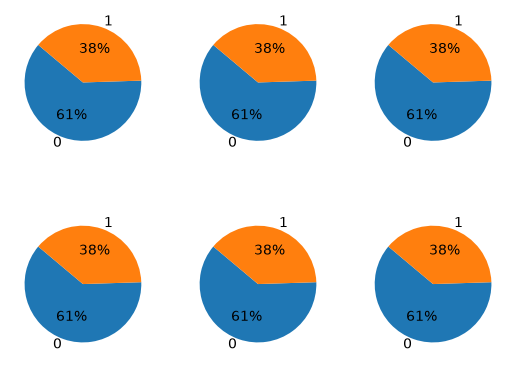

In [55]:
plt.Figure(figsize=(9,4))
for i , col in enumerate(cat_col):
    plt.subplot(2,3,i+1)
    unique=df["Survived"].value_counts()
    count=unique.values
    categories=unique.index
    plt.pie(count,labels=categories,startangle=140,autopct="%1.1d%%")

    

Text(0, 0.5, 'fare')

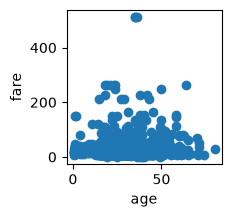

In [57]:
plt.figure(figsize=(2,2))
plt.scatter(df["Age"],df['Fare'])
plt.xlabel("age")
plt.ylabel("fare")

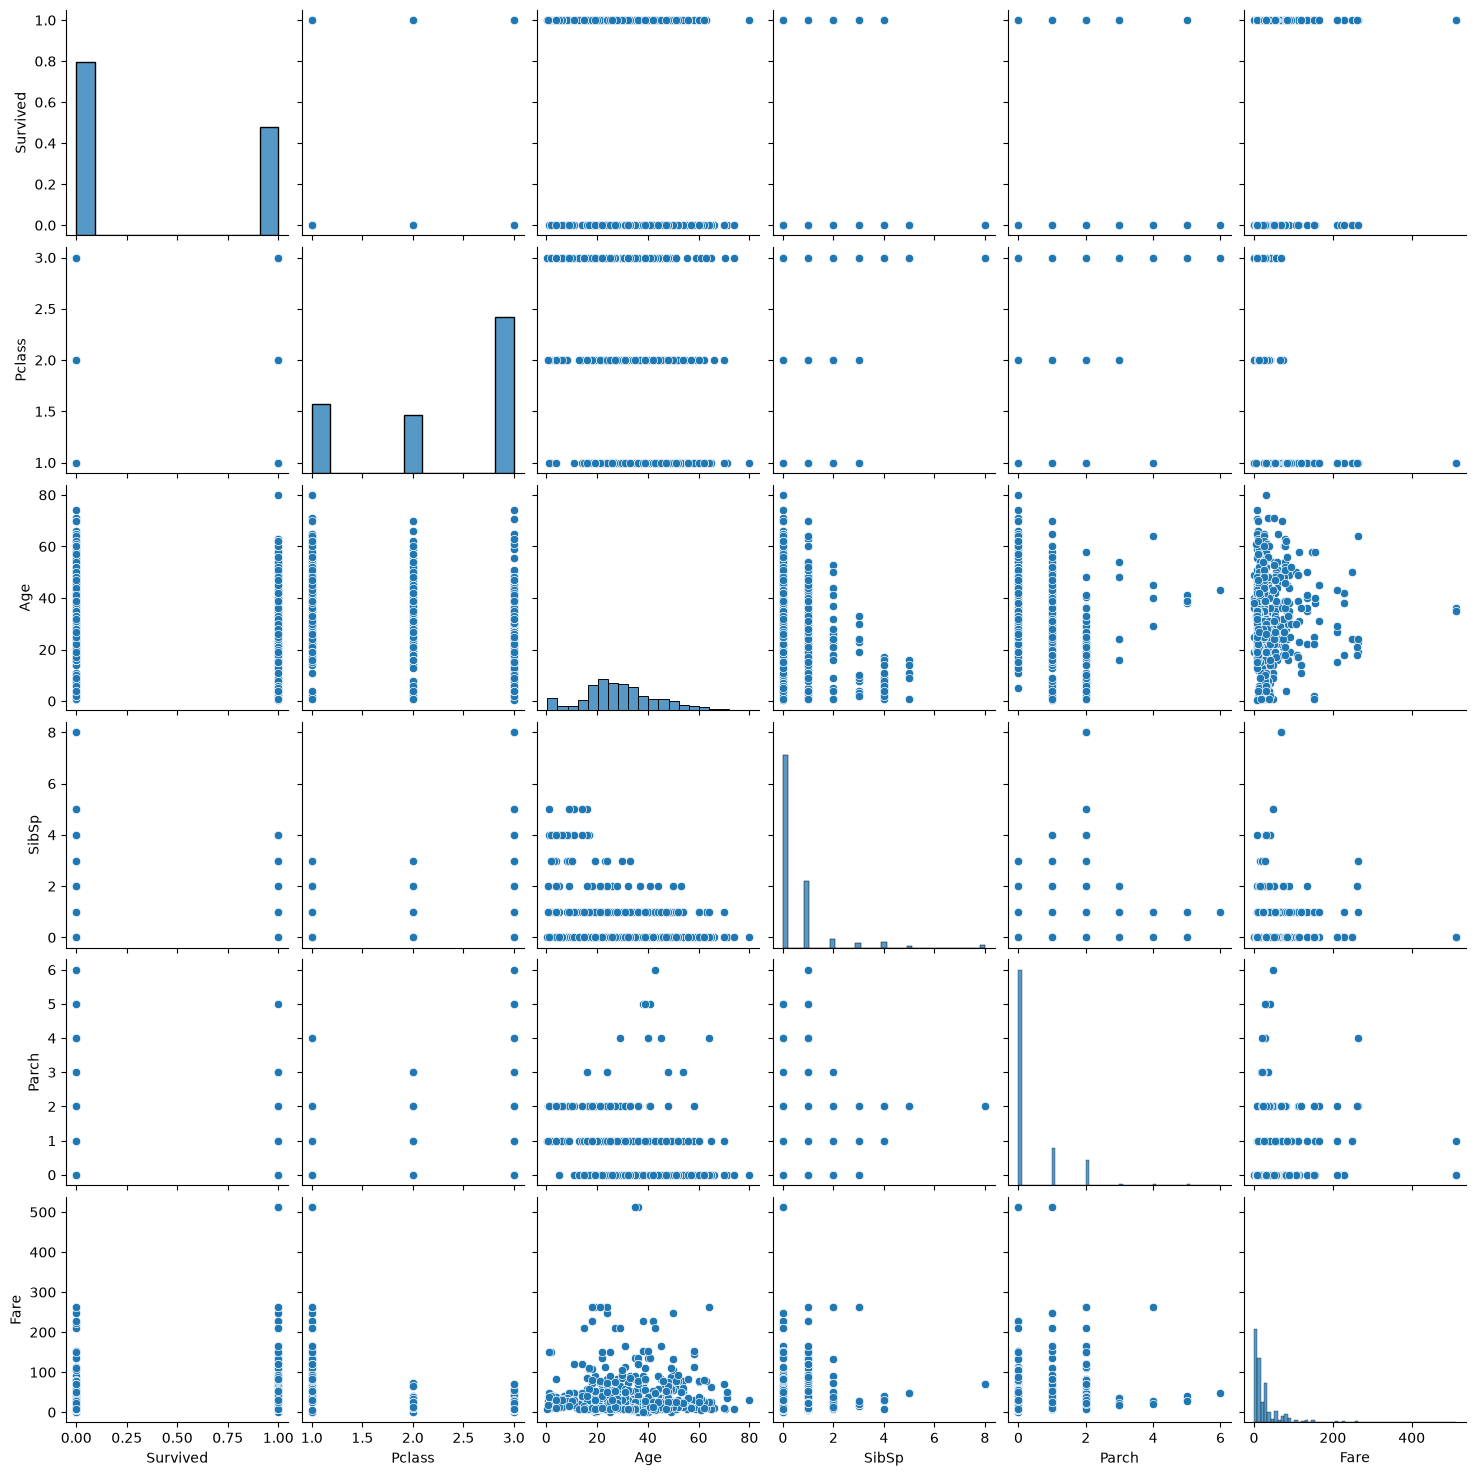

In [58]:
sns.pairplot(df)

<Axes: >

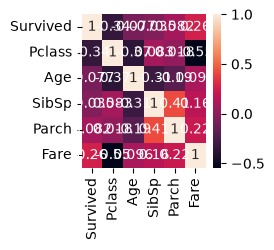

In [60]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(2,2))
sns.heatmap(corr,annot=True)